### [work0622_이한이] <hr>

- **[0]모듈 로딩**

In [3]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import importlib
import cv_utils
importlib.reload(cv_utils)

from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report # 평가
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

- **[1]데이터 준비**

In [4]:
DATA_FILE= './iris.csv'

#  데이터 로딩
dataDF= pd.read_csv(DATA_FILE)
dataDF

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [12]:
print("============== 구조 요약 ==============")
dataDF.info()
# 데이터프레임의 전체 구조 확인
# - 행 개수
# - 컬럼 개수
# - 컬럼명
# - 결측치 여부
# - 데이터 타입
# - 메모리 사용량


print("\n============== 상위 3개 행 ==============")
display(dataDF.head(3))
# 데이터가 어떤 형태로 들어있는지 앞에서부터 3개 행 확인


print("\n============== 기초 통계 요약 ==============")
display(dataDF.describe(include='all'))
# 데이터의 기초 통계 확인
# include='all' : 숫자형 컬럼뿐만 아니라 문자형 컬럼까지 함께 확인

============== 구조 요약 ==============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

============== 상위 3개 행 ==============


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa



============== 기초 통계 요약 ==============


,sepal.length,sepal.width,petal.length,petal.width,variety
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


- **[2]데이터 전처리**

In [13]:
dataDF.variety=dataDF.variety.astype('category')

display(dataDF.dtypes)

sepal.length     float64
sepal.width      float64
petal.length     float64
petal.width      float64
variety         category
dtype: object

- **[3]학습용|테스트용 데이터셋 준비**

In [15]:
## => 피쳐와 타겟 분리
featureDF = dataDF[dataDF.columns[:-1]] # 특징은 ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
targetSR  = dataDF[dataDF.columns[-1]] # 맞춰야하는 정답 컬럼= variety

print(f'피쳐 : {featureDF.shape}, 타겟 : {targetSR.shape}')

피쳐 : (150, 4), 타겟 : (150,)


In [16]:
## => 학습용|테스트용 분리 : 분류     => 타겟 클래스 비율 유지 stratify 매개변수 설정 
##                        재현성    => random_state 매개변수 설정
##                        피쳐 차원 => 2D
##                        타겟 차원 => 1D  
X_train, X_test, y_train, y_test = train_test_split(featureDF, 
                                                    targetSR, 
                                                    test_size=0.2,
                                                    random_state = 10,
                                                    stratify = targetSR
                                                    )

In [ ]:
## => 확인
print(f'학습용 : {X_train.shape},  {y_train.shape} 테스트용 : {X_test.shape}, {y_test.shape}')
print(f'학습용 클래스 데이터 구성\n', y_train.value_counts().tolist())
print(f'\n테스트용 클래스 데이터 구성\n', y_test.value_counts().tolist())




학습용 : (120, 4),  (120,) 테스트용 : (30, 4), (30,)
학습용 클래스 데이터 구성
 [40, 40, 40]

테스트용 클래스 데이터 구성
 [10, 10, 10]


- **[4]하이퍼파라미터 튜닝 및 교차 검증**
    * 모든 파라미터 조합 튜닝
    * 선택 파라미터 조합 튜닝
    * 2개 결과 비교

In [18]:

# 모델 생성
kModel = KNeighborsClassifier()

# 하이퍼파라미터 후보
param_dict = {
    'n_neighbors': range(1, 51, 2),
    'p': [1, 2],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# 교차검증 방식
skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

- **(1) 모든 하이퍼파라메터 조합-> GridSearchCV**

In [22]:
## => 학습 후 설정된 모델 파라미터 확인
## - cv_results_ : 각 모델의 교차검증 결과 저장 dict 형식


gsModel = GridSearchCV(
    kModel,
    param_grid=param_dict,
    cv=skFold,
    return_train_score=True
)

gsModel.fit(X_train, y_train)

cv_resultDF = pd.DataFrame(gsModel.cv_results_)

print("GridSearchCV 최적 파라미터:", gsModel.best_params_)
print("GridSearchCV 최고 검증 점수:", gsModel.best_score_)
print("GridSearchCV 테스트 점수:", gsModel.best_estimator_.score(X_test, y_test))

## - best_estimator_ : 최고 성능의 조합으로 재학습한 모델인스턴스
gs_best_model = gsModel.best_estimator_

GridSearchCV 최적 파라미터: {'algorithm': 'brute', 'n_neighbors': 9, 'p': 2}
GridSearchCV 최고 검증 점수: 0.9583333333333334
GridSearchCV 테스트 점수: 1.0


- **(2) 선택 조합 튜닝-> RandomizedSearchCV**

In [27]:
## -------------------------------------------------
## => RandomizedSearchCV 인스턴스 생성 및 진행
## - GridSearchCV의 느린 속도 개선 
## - 지정된 개수 만큼의 모델을 조합 => 속도 빠름
## - 단점 : GridSearchCV보다 최적의 조합 아닐 수 도 있음
## - cv 파라미터 
##   * 기본값 : 5 
##   * 학습 시 전달하는 y값에 따라서 KFold, StratifiedKFold 설정 
## - random_state 파라미터
##   * 재현성 위해서 설정
## - n_iter 파라미터
##   * 무작위 조합할 모델 개수 설정
## --------------------------------------------
## => 모델인스턴스 : KNN
kModel = KNeighborsClassifier()

## => 모델의 하이퍼파라미터 Dict
param_dict ={'n_neighbors' : range(1,51,2), 
             'p': [1,2], 
             'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

## => 교차검증 인스턴스 생성
skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

## => 튜닝 및 교차검증 진행 인스턴스 
rsModel = RandomizedSearchCV(kModel, 
                             param_distributions=param_dict, 
                             cv=skFold, 
                             n_iter=50,
                             random_state=10,
                             return_train_score=True) 

rsModel.fit(X_train, y_train)


print("RandomizedSearchCV 최적 파라미터:", rsModel.best_params_)
print("RandomizedSearchCV 최고 검증 점수:", rsModel.best_score_)
print("RandomizedSearchCV 테스트 점수:", rsModel.best_estimator_.score(X_test, y_test))


## - best_estimator_ : 최고 성능의 조합으로 재학습한 모델인스턴스

rs_best_model = rsModel.best_estimator_



## 조합 모델별 학습 성능 
cv_resultDF = pd.DataFrame(rsModel.cv_results_)
cv_resultDF.info()

RandomizedSearchCV 최적 파라미터: {'p': 2, 'n_neighbors': 9, 'algorithm': 'brute'}
RandomizedSearchCV 최고 검증 점수: 0.9583333333333334
RandomizedSearchCV 테스트 점수: 1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_fit_time       50 non-null     float64
 1   std_fit_time        50 non-null     float64
 2   mean_score_time     50 non-null     float64
 3   std_score_time      50 non-null     float64
 4   param_p             50 non-null     int64  
 5   param_n_neighbors   50 non-null     int64  
 6   param_algorithm     50 non-null     object 
 7   params              50 non-null     object 
 8   split0_test_score   50 non-null     float64
 9   split1_test_score   50 non-null     float64
 10  split2_test_score   50 non-null     float64
 11  split3_test_score   50 non-null     float64
 12  split4_test_score   50 non-null     float64
 13  m

- **(3) 두 결과 비교**

In [28]:
compareDF = pd.DataFrame({
    'method': ['GridSearchCV', 'RandomizedSearchCV'],
    'best_params': [gsModel.best_params_, rsModel.best_params_],
    'best_cv_score': [gsModel.best_score_, rsModel.best_score_],
    'test_score': [
        gsModel.best_estimator_.score(X_test, y_test),
        rsModel.best_estimator_.score(X_test, y_test)
    ]
})

compareDF

,method,best_params,best_cv_score,test_score
0,GridSearchCV,"{'algorithm': 'brute', 'n_neighbors': 9, 'p': 2}",0.958333,1.0
1,RandomizedSearchCV,"{'p': 2, 'n_neighbors': 9, 'algorithm': 'brute'}",0.958333,1.0


- **[5]학습 결과 분석 및 시각화**

In [29]:
## => 모델 조합별 교차검증 결과
cv_resultDF.info()

## => 확인하고 싶은 컬럼만 선택
cols  = ['rank_test_score','mean_test_score', 'mean_train_score', 'params']
selDF = cv_resultDF[cols]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_fit_time       50 non-null     float64
 1   std_fit_time        50 non-null     float64
 2   mean_score_time     50 non-null     float64
 3   std_score_time      50 non-null     float64
 4   param_p             50 non-null     int64  
 5   param_n_neighbors   50 non-null     int64  
 6   param_algorithm     50 non-null     object 
 7   params              50 non-null     object 
 8   split0_test_score   50 non-null     float64
 9   split1_test_score   50 non-null     float64
 10  split2_test_score   50 non-null     float64
 11  split3_test_score   50 non-null     float64
 12  split4_test_score   50 non-null     float64
 13  mean_test_score     50 non-null     float64
 14  std_test_score      50 non-null     float64
 15  rank_test_score     50 non-null     int32  
 16  split0_tra

In [30]:
selDF.sort_values(by=['rank_test_score']).head(3)

,rank_test_score,mean_test_score,mean_train_score,params
30,1,0.958333,0.972917,"{'p': 2, 'n_neighbors': 9, 'algorithm': 'brute'}"
0,2,0.950000,0.972917,"{'p': 2, 'n_neighbors': 9, 'algorithm': 'ball_..."
5,2,0.950000,0.956250,"{'p': 2, 'n_neighbors': 19, 'algorithm': 'auto'}"


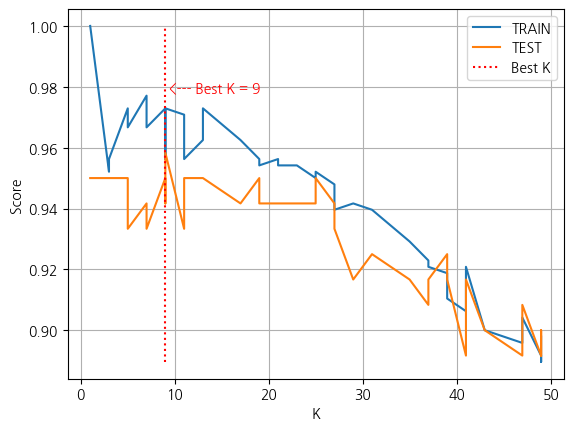

In [38]:
## K 기준 정렬
cv_resultDF = cv_resultDF.sort_values('param_n_neighbors')

## 학습 점수, 검증 점수 그래프
plt.plot(
    cv_resultDF['param_n_neighbors'],
    cv_resultDF['mean_train_score'],
    label='TRAIN'
)

plt.plot(
    cv_resultDF['param_n_neighbors'],
    cv_resultDF['mean_test_score'],
    label='TEST'
)

## 베스트 K
plt.vlines(
    rsModel.best_params_['n_neighbors'],
    cv_resultDF['mean_train_score'].min(),
    cv_resultDF['mean_train_score'].max(),
    colors='red',
    linestyles='dotted',
    label='Best K'
)

plt.text(
    rsModel.best_params_['n_neighbors'],
    rsModel.best_score_ + 0.02,
    f" <--- Best K = {rsModel.best_params_['n_neighbors']}",
    color='red'
)

## 그래프 설정
plt.legend()
plt.xlabel('K')
plt.ylabel('Score')
plt.grid()
plt.show()

- **[6]예측 및 평가**
    * 테스트 데이터 기반 예측
    * 사용자 입__력 기반 예측

In [31]:
## 예측 진행
y_pre = gs_best_model.predict(X_test)

## 정답과 예측 비교 : 정답과 오답 개수
correct   = (y_pre == y_test).sum()
incorrect = y_pre.shape[0] - correct

print(f'[테스트 예측 평가] 정답 개수 : {correct}개, 오답 개수 : {incorrect}개')

[테스트 예측 평가] 정답 개수 : 30개, 오답 개수 : 0개


In [33]:
type(X_test)

pd.DataFrame

pandas.core.frame.DataFrame

In [34]:
## 사용자로부터 입력받은 값 예측
in_data = input("붓꽃 정보 입력(예: 0.12 0.08 1.23 1.44):").split(" ")
newDF   = pd.DataFrame([in_data], columns=X_train.columns)
print(newDF)

## 예측 진행
y_pre = gs_best_model.predict(newDF)

print(y_pre)

  sepal.length sepal.width petal.length petal.width
0         0.15        0.02         4.00        1.04
['Versicolor']
